# Compare saved cobalt L-edge exit waves

Choose HDF5 files and energies below, then run all cells. This notebook compares CR at different energies. Each file is plotted independently so different simulation runs can be compared.

The complex ideal sample exit field is read from `results/<entry>/holograms/exit_waves/<component>`. These are the saved exit waves before detector noise. The notebook shows their amplitude and phase, plus the amplitude and phase of their centered FFT. FFT amplitudes use a logarithmic color scale; fields are not normalized.

The second plot shows the complex **exit-wave ratio at numerator energy / exit wave at denominator energy**, separately for each file and component. Its amplitude is the amplitude ratio; its phase is the wrapped phase difference. Pixels with negligible denominator amplitude are masked.

Only selected fields are read, files are opened read-only and closed immediately, and figures are displayed and closed one at a time. Requires NumPy, h5py, Matplotlib and Jupyter.

Azimuthal profiles below compare the same two energies in real and Fourier space, including amplitude differences, ratios, and circularly averaged phase differences. They retain the full-resolution data and absolute amplitudes.


In [45]:
# Sample-to-detector propagation (independent of multislice).
detector_propagation_method = "fraunhofer"  # Opt in with "rayleigh_sommerfeld".
# Direct Rayleigh-Sommerfeld is expensive: try small grids first.
# This notebook reads saved data or stops at the sample exit; pass this
# setting to DetectorConfig when extending it to propagate to a detector.


In [46]:
from pathlib import Path
import numpy as np
import h5py
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

%matplotlib inline


In [47]:
# Edit these paths and labels. Absolute paths work from any working directory.
FILES = {
    #"OH2E+Pt": Path("/home/riccardo/Desktop/Github/Data/fomocid/12_cobalt_l_edge_energy_sweep/cobalt_l_edge_energy_sweep.h5"),
    #"OH1E+Pt": Path("/home/riccardo/Desktop/Github/Data/fomocid/12_cobalt_l_edge_energy_sweep/cobalt_l_edge_energy_sweep_001.h5"),
    #"OH1E+Co2E": Path("/home/riccardo/Desktop/Github/Data/fomocid/12_cobalt_l_edge_energy_sweep/cobalt_l_edge_energy_sweep_002.h5"),
    #"OH2E+vac": Path("/home/riccardo/Desktop/Github/Data/fomocid/12_cobalt_l_edge_energy_sweep/cobalt_l_edge_energy_sweep_003.h5"),
    #"OH2E+Co2E": Path("/home/riccardo/Desktop/Github/Data/fomocid/12_cobalt_l_edge_energy_sweep/cobalt_l_edge_energy_sweep_004.h5"),
    #"OH1E+vac": Path("/home/riccardo/Desktop/Github/Data/fomocid/12_cobalt_l_edge_energy_sweep/cobalt_l_edge_energy_sweep_005.h5"),
    #"OH1E+Co2E(thin)": Path("/home/riccardo/Desktop/Github/Data/fomocid/12_cobalt_l_edge_energy_sweep/cobalt_l_edge_energy_sweep_006.h5"),
    #"OH1E+1.2funnel": Path("/home/riccardo/Desktop/Github/Data/fomocid/12_cobalt_l_edge_energy_sweep/cobalt_l_edge_energy_sweep_014.h5"),
    #"OH2E+1.2funnel": Path("/home/riccardo/Desktop/Github/Data/fomocid/12_cobalt_l_edge_energy_sweep/cobalt_l_edge_energy_sweep_015.h5"),
    #"OH2E+1.75funnel": Path("/home/riccardo/Desktop/Github/Data/fomocid/12_cobalt_l_edge_energy_sweep/cobalt_l_edge_energy_sweep_016.h5"),
    "OH2E+Mickey": Path("/home/riccardo/Desktop/Github/Data/fomocid/12_cobalt_l_edge_energy_sweep/cobalt_l_edge_energy_sweep_017.h5"),
}
ENERGIES_EV = [788.3, 780.0]
COMPONENTS = ["CR"]  # Compare CR across energies.
RATIO_ENERGIES_EV = (788.3, 780.0)  # numerator, denominator; within each file
ENERGY_TOLERANCE_EV = 1e-6  # Require a saved energy, without silently picking a neighbour.
CROP_TO_OBJECT_HOLE = True  # Exit-wave and ratio display only; FFT uses the FULL field.
DENOMINATOR_RELATIVE_FLOOR = 1e-8  # Fraction of peak denominator amplitude.
MAX_DISPLAY_PIXELS = 768  # Downsample only the display, never the FFT or ratio calculation.
# Azimuthal profiles use the full-resolution data, independent of display binning.
AZIMUTHAL_BIN_WIDTH_PIXELS = 1.0  # Spatial annulus width in source pixels.
AZIMUTHAL_CENTER_YX = None       # None: center of the displayed OH crop; or (y, x) within that crop.
AZIMUTHAL_MIN_PHASE_RESULTANT = 0.1  # Mask circular means with poorly defined phase direction.


In [48]:
def index_file(path):
    """Inspect available results without loading image arrays."""
    entries = []
    with h5py.File(Path(path).expanduser(), "r") as handle:
        if "results" not in handle:
            raise ValueError(f"{path}: missing results group; expected tutorial 12 output.")
        for key, group in handle["results"].items():
            if "energy_eV" in group.attrs and "holograms/exit_waves" in group:
                entries.append((float(group.attrs["energy_eV"]), key,
                                tuple(group["holograms/exit_waves"].keys())))
    return sorted(entries)


def load_exit_wave(path, entries, energy, component):
    matches = [entry for entry in entries if abs(entry[0] - energy) <= ENERGY_TOLERANCE_EV]
    if len(matches) != 1:
        raise ValueError(f"{path}: expected one match for {energy:g} eV, found {len(matches)}. "
                         f"Available energies: {[entry[0] for entry in entries]}")
    actual_energy, key, components = matches[0]
    if component not in components:
        raise ValueError(f"{path}, {energy:g} eV: {component!r} missing; available: {components}")
    with h5py.File(Path(path).expanduser(), "r") as handle:
        group = handle[f"results/{key}"]
        dataset = group[f"holograms/exit_waves/{component}"]
        if dataset.ndim == 2:
            wave = dataset[...]
        elif dataset.ndim == 3 and dataset.shape[0] > 0:
            # Older outputs may contain frames: average the complex fields incrementally.
            wave = np.zeros(dataset.shape[1:], dtype=np.complex128)
            for index in range(dataset.shape[0]):
                wave += dataset[index]
            wave /= dataset.shape[0]
        else:
            raise ValueError(f"Unsupported exit-wave shape: {dataset.shape}")
        crop = (slice(None), slice(None))
        if CROP_TO_OBJECT_HOLE:
            if "sample_oh_slices" not in group.attrs:
                raise ValueError("Object-hole crop is missing; set CROP_TO_OBJECT_HOLE=False.")
            y0, y1, x0, x1 = map(int, group.attrs["sample_oh_slices"])
            crop = (slice(y0, y1), slice(x0, x1))
    return wave, crop, actual_energy


def centered_fft(wave):
    return np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(wave), norm="ortho"))


def complex_ratio(numerator, denominator):
    if numerator.shape != denominator.shape:
        raise ValueError("Ratio fields must have matching sample grids.")
    if not 0 <= DENOMINATOR_RELATIVE_FLOOR < 1:
        raise ValueError("DENOMINATOR_RELATIVE_FLOOR must lie in [0, 1).")
    amplitude = np.abs(denominator)
    finite = np.isfinite(amplitude)
    peak = amplitude[finite].max() if finite.any() else 0.0
    valid = np.isfinite(numerator) & finite & (amplitude > peak * DENOMINATOR_RELATIVE_FLOOR)
    ratio = np.full(numerator.shape, np.nan + 1j * np.nan, dtype=np.complex128)
    np.divide(numerator, denominator, out=ratio, where=valid)
    return ratio


def bin_display_image(image, pixels=1, phase=False):
    """Average display pixels in blocks, retaining partial edge blocks."""
    if isinstance(pixels, (bool, np.bool_)) or not isinstance(pixels, (int, np.integer)) or pixels < 1:
        raise ValueError("DISPLAY_BIN_PIXELS must be a positive integer (1 disables binning).")
    if pixels == 1:
        return image
    valid = np.isfinite(image)
    values = np.zeros(image.shape, dtype=complex if phase else float)
    values[valid] = np.exp(1j * image[valid]) if phase else image[valid]
    rows = np.arange(0, image.shape[0], pixels)
    cols = np.arange(0, image.shape[1], pixels)
    sums = np.add.reduceat(np.add.reduceat(values, rows, axis=0), cols, axis=1)
    counts = np.add.reduceat(np.add.reduceat(valid.astype(np.int64), rows, axis=0), cols, axis=1)
    means = np.full(sums.shape, np.nan, dtype=sums.dtype)
    np.divide(sums, counts, out=means, where=counts > 0)
    if phase:
        result = np.angle(means)
        result[np.abs(means) < 1e-12] = np.nan  # No defined mean direction.
        return result
    return means


def show_image(ax, image, title, phase=False, logarithmic=False, bin_pixels=1):
    image = bin_display_image(image, bin_pixels, phase=phase)
    stride = max(1, int(np.ceil(max(image.shape) / MAX_DISPLAY_PIXELS)))
    image = image[::stride, ::stride]
    options = {"cmap": "twilight", "vmin": -np.pi, "vmax": np.pi} if phase else {"cmap": "viridis"}
    if logarithmic:
        positive = image[np.isfinite(image) & (image > 0)]
        if positive.size:
            vmax = float(positive.max())
            options["norm"] = LogNorm(vmin=max(float(positive.min()), vmax * 1e-8), vmax=vmax * (1 + 1e-12))
        image = np.ma.masked_less_equal(image, 0)
    artist = ax.imshow(np.ma.masked_invalid(image), interpolation="nearest", **options)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.figure.colorbar(artist, ax=ax, shrink=0.8, label="rad" if phase else "amplitude")


def show_split_image(ax, left, right, title, energies, phase=False, logarithmic=False):
    """Join spatially corresponding halves; use one color scale for both energies."""
    if left.shape != right.shape or left.shape[1] < 2:
        raise ValueError("Split comparison requires matching images at least two columns wide.")
    stride = max(1, int(np.ceil(max(left.shape) / MAX_DISPLAY_PIXELS)))
    left, right = left[::stride, ::stride], right[::stride, ::stride]
    if left.shape[1] < 2:
        raise ValueError("Increase MAX_DISPLAY_PIXELS to show both halves.")
    midpoint = left.shape[1] // 2
    combined = np.concatenate((left[:, :midpoint], right[:, midpoint:]), axis=1)
    show_image(ax, combined, title, phase=phase, logarithmic=logarithmic)
    ax.axvline(midpoint - 0.5, color="white", linewidth=1, linestyle="--")
    for position, energy in ((0.02, energies[0]), (0.98, energies[1])):
        ax.text(position, 0.98, f"{energy:g} eV", transform=ax.transAxes,
                ha="left" if position < 0.5 else "right", va="top", color="white",
                bbox={"facecolor": "black", "alpha": 0.6, "edgecolor": "none", "pad": 2})


def plot_exit_wave_pair(path, entries, label, energy_pair, component):
    left, crop_left, energy_left = load_exit_wave(path, entries, energy_pair[0], component)
    right, crop_right, energy_right = load_exit_wave(path, entries, energy_pair[1], component)
    if left.shape != right.shape or crop_left != crop_right:
        raise ValueError("Paired energies must have the same sample grid and object-hole crop.")
    fft_left, fft_right = centered_fft(left), centered_fft(right)
    energies = (energy_left, energy_right)
    fig, axes = plt.subplots(1, 4, figsize=(15, 3.8), layout="constrained")
    try:
        fig.suptitle(f"{label} | {component} | left: {energy_left:g} eV / right: {energy_right:g} eV")
        show_split_image(axes[0], np.abs(left[crop_left]), np.abs(right[crop_right]),
                         "Exit-wave amplitude", energies)
        show_split_image(axes[1], np.angle(left[crop_left]), np.angle(right[crop_right]),
                         "Exit-wave phase", energies, phase=True)
        show_split_image(axes[2], np.abs(fft_left), np.abs(fft_right),
                         "Full-field FFT amplitude (log)", energies, logarithmic=True)
        show_split_image(axes[3], np.angle(fft_left), np.angle(fft_right),
                         "Full-field FFT phase", energies, phase=True)
        plt.show()
    finally:
        plt.close(fig)


def plot_energy_ratio(path, entries, label, component, bin_pixels=1):
    numerator_energy, denominator_energy = RATIO_ENERGIES_EV
    numerator, crop, actual_n = load_exit_wave(path, entries, numerator_energy, component)
    denominator, _, actual_d = load_exit_wave(path, entries, denominator_energy, component)
    if numerator.shape != denominator.shape:
        raise ValueError("Energy comparison requires matching full sample grids.")
    ratio = complex_ratio(numerator[crop], denominator[crop])
    # Compare the transforms of the full fields on the same sample-frequency grid.
    fft_ratio = complex_ratio(centered_fft(numerator), centered_fft(denominator))
    fig, axes = plt.subplots(1, 4, figsize=(15, 3.6), layout="constrained")
    try:
        fig.suptitle(f"{label} | {component} | {actual_n:g} eV / {actual_d:g} eV | bin {bin_pixels}×{bin_pixels}")
        show_image(axes[0], np.abs(ratio), "Exit-wave amplitude ratio", bin_pixels=bin_pixels)
        show_image(axes[1], np.angle(ratio), "Exit-wave phase difference", phase=True, bin_pixels=bin_pixels)
        show_image(axes[2], np.abs(fft_ratio), "FFT amplitude ratio", bin_pixels=bin_pixels)
        show_image(axes[3], np.angle(fft_ratio), "FFT phase difference", phase=True, bin_pixels=bin_pixels)
        plt.show()
    finally:
        plt.close(fig)

## Available saved energies
Run this cell after editing `FILES` to inspect energies and components. Missing selections produce an explicit error. Entries without saved exit waves are ignored, allowing inspection of interrupted runs. Plot colors are scaled independently, except phase which always spans −π to π; use colorbars for amplitude comparisons.

In [49]:
catalog = {}
if MAX_DISPLAY_PIXELS < 1 or ENERGY_TOLERANCE_EV < 0:
    raise ValueError("MAX_DISPLAY_PIXELS must be positive and ENERGY_TOLERANCE_EV nonnegative.")
if not FILES:
    print("Add your HDF5 paths to FILES above, then rerun from that cell.")
for label, path in FILES.items():
    catalog[label] = index_file(path)
    print(f"{label}: {Path(path).expanduser()}")
    for energy, _, components in catalog[label]:
        print(f"  {energy:g} eV: {', '.join(components)}")

OH2E+Mickey: /home/riccardo/Desktop/Github/Data/fomocid/12_cobalt_l_edge_energy_sweep/cobalt_l_edge_energy_sweep_017.h5
  779.5 eV: CL, CR, diff, sum
  780 eV: CL, CR, diff, sum
  784 eV: CL, CR, diff, sum
  787 eV: CL, CR, diff, sum
  788.3 eV: CL, CR, diff, sum


## Exit waves and their FFT
Energies are grouped in consecutive pairs from `ENERGIES_EV`. Every panel joins the **left half of the first energy** with the **right half of the second energy**, preserving pixel positions. The dashed line marks the join, and both halves share one color scale. With the current controls, 777 eV is on the left and 780 eV on the right.

The FFT always uses the complete saved sample field before splitting, even when the exit-wave display is cropped to the object hole. Spatial and Fourier images are shown in array coordinates. These split views show complementary spatial halves; the ratio panels below compare corresponding pixels across the whole displayed region.


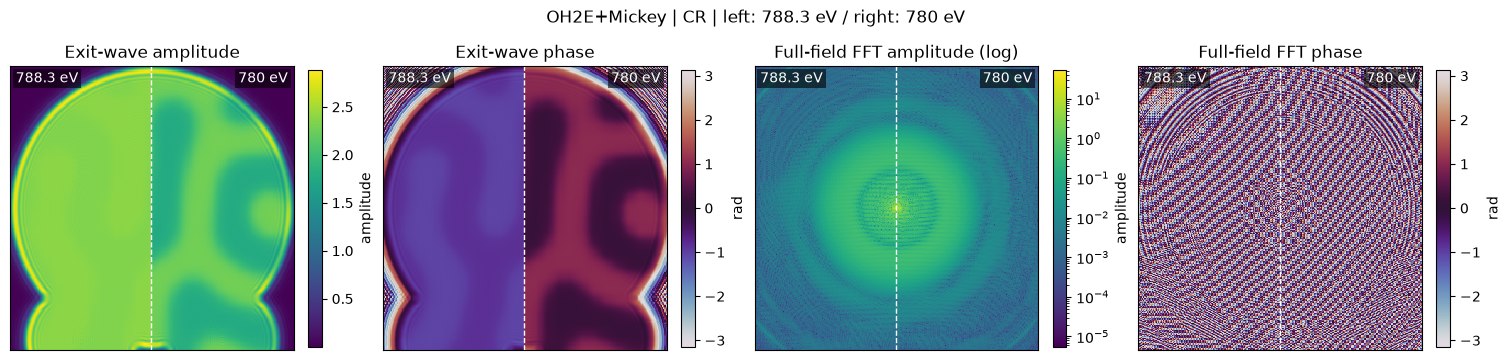

In [50]:
if len(ENERGIES_EV) % 2:
    raise ValueError("Choose an even number of ENERGIES_EV to compare consecutive pairs.")
for label, path in FILES.items():
    for index in range(0, len(ENERGIES_EV), 2):
        for component in COMPONENTS:
            plot_exit_wave_pair(path, catalog[label], label, ENERGIES_EV[index:index + 2], component)


## Ratio between two energies
The ratio compares CR at both energies within each file. Identical complex fields give amplitude ratio 1 and phase difference 0 wherever the denominator is valid. The same criterion applies to the FFT ratio. Ratios retain absolute amplitude and phase; there is no normalization or phase alignment. Tutorial 12 keeps the sample grid fixed within a sweep. No ratio is taken between different files. Blank pixels mark undefined ratios or denominator amplitudes below the selected threshold.

The last two panels compare `FFT(exit_wave at numerator energy) / FFT(exit_wave at denominator energy)`, using the full fields even when the exit-wave display is cropped. FFT amplitude ratios and wrapped phase differences use the same denominator masking rule. The default comparison is **777 eV / 780 eV**.


`DISPLAY_BIN_PIXELS` in the last cell averages blocks of displayed ratio pixels after the ratios are calculated. Amplitudes use arithmetic means; phases use circular means. Masked pixels are ignored, fully masked bins stay blank, and partial edge bins are retained.


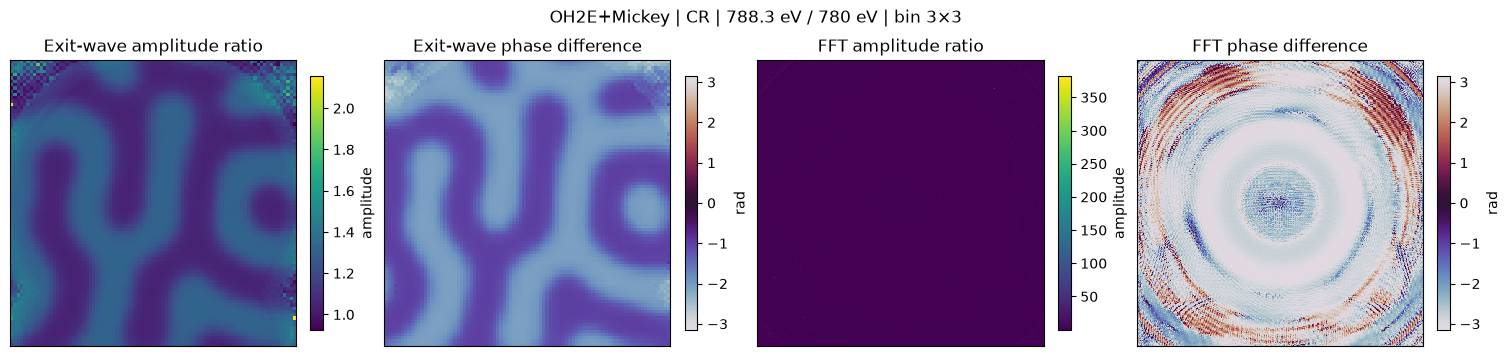

In [51]:
# Display-only binning: 1 = original pixels, 2 = average 2×2, 4 = average 4×4, etc.
# Applies to exit-wave and FFT ratios. Phase uses circular averaging.
DISPLAY_BIN_PIXELS = 3

for label, path in FILES.items():
    for component in COMPONENTS:
        plot_energy_ratio(path, catalog[label], label, component, bin_pixels=DISPLAY_BIN_PIXELS)

## Azimuthal averages: differences between the two energies

For every file and component, use `RATIO_ENERGIES_EV = (numerator, denominator)` to compare full-resolution fields. **No intensity normalization or global phase alignment is applied.**

- **Top row:** circular annuli centered on the cropped object-hole image (or `AZIMUTHAL_CENTER_YX`). Radius is in **source pixels**. The center override is relative to the crop, not the full sample.
- **Bottom row:** annuli around zero frequency in the **full-field FFT**, using the true FFT frequency coordinates. Radius is in **cycles per source pixel**, including rectangular grids. It is not an energy-dependent detector angle.

The four columns show the two mean amplitudes, their signed difference (numerator minus denominator), their ratio (numerator divided by denominator), and the **circular mean of the pixelwise wrapped phase difference**. The amplitude ratio is the ratio of annular means, not the mean of pixelwise ratios. A common finite-pixel mask is used for both amplitudes. Phase averaging additionally excludes negligible amplitudes at either energy; rings with low circular resultant are left blank.

Only complete annuli inside the image are retained, avoiding corner-biased averages. Empty/invalid bins remain undefined. The denominator floor and phase-resultant threshold are configurable. `MAX_DISPLAY_PIXELS` and `DISPLAY_BIN_PIXELS` do not affect these calculations. Azimuthal averaging can hide directional domains and fringes, so retain the two-dimensional comparisons above.


In [52]:
def azimuthal_pair_profiles(numerator, denominator, *, fourier=False, center_yx=None):
    """Compare annular amplitudes and circular pixelwise phase differences."""
    if numerator.shape != denominator.shape or numerator.ndim != 2:
        raise ValueError("Azimuthal comparison requires matching 2-D fields.")
    if not np.isfinite(AZIMUTHAL_BIN_WIDTH_PIXELS) or AZIMUTHAL_BIN_WIDTH_PIXELS <= 0:
        raise ValueError("AZIMUTHAL_BIN_WIDTH_PIXELS must be finite and positive.")
    if not 0 <= AZIMUTHAL_MIN_PHASE_RESULTANT <= 1:
        raise ValueError("AZIMUTHAL_MIN_PHASE_RESULTANT must be in [0, 1].")
    if not 0 <= DENOMINATOR_RELATIVE_FLOOR < 1:
        raise ValueError("DENOMINATOR_RELATIVE_FLOOR must be in [0, 1).")
    ny, nx = numerator.shape
    if fourier:
        x = np.fft.fftshift(np.fft.fftfreq(nx))
        y = np.fft.fftshift(np.fft.fftfreq(ny))
        width = AZIMUTHAL_BIN_WIDTH_PIXELS / max(ny, nx)
        radius_limit = min(-x[0], x[-1], -y[0], y[-1])
    else:
        cy, cx = ((ny-1)/2, (nx-1)/2) if center_yx is None else center_yx
        if not (np.isfinite(cy) and np.isfinite(cx) and 0 <= cy < ny and 0 <= cx < nx):
            raise ValueError("AZIMUTHAL_CENTER_YX must lie inside the cropped field.")
        x, y = np.arange(nx)-cx, np.arange(ny)-cy
        width = float(AZIMUTHAL_BIN_WIDTH_PIXELS)
        radius_limit = min(cx+.5, nx-.5-cx, cy+.5, ny-.5-cy)
    n_bins = int(np.floor(radius_limit / width))
    if n_bins < 1:
        raise ValueError("No complete annuli: reduce bin width or adjust the center/crop.")
    # Broadcasting avoids storing two full coordinate meshes.
    radii = np.hypot(y[:, None], x[None, :])
    bins = np.floor(radii / width).astype(int)
    inside = bins < n_bins
    common = inside & np.isfinite(numerator) & np.isfinite(denominator)
    counts = np.bincount(bins[common], minlength=n_bins)

    def mean(values, mask):
        count = np.bincount(bins[mask], minlength=n_bins)
        total = np.bincount(bins[mask], weights=values[mask], minlength=n_bins)
        result = np.full(n_bins, np.nan)
        np.divide(total, count, out=result, where=count > 0)
        return result

    amp_n, amp_d = np.abs(numerator), np.abs(denominator)
    mean_n, mean_d = mean(amp_n, common), mean(amp_d, common)
    peak_d = amp_d[common].max() if common.any() else 0.0
    peak_n = amp_n[common].max() if common.any() else 0.0
    ratio = np.full(n_bins, np.nan)
    ratio_valid = (counts > 0) & (mean_d > peak_d * DENOMINATOR_RELATIVE_FLOOR)
    np.divide(mean_n, mean_d, out=ratio, where=ratio_valid)
    phase_mask = common & (amp_d > peak_d*DENOMINATOR_RELATIVE_FLOOR) & (amp_n > peak_n*DENOMINATOR_RELATIVE_FLOOR)
    phase_delta = np.angle(numerator) - np.angle(denominator)
    cos_mean, sin_mean = mean(np.cos(phase_delta), phase_mask), mean(np.sin(phase_delta), phase_mask)
    resultant = np.hypot(cos_mean, sin_mean)
    phase = np.arctan2(sin_mean, cos_mean)
    phase[resultant <= max(AZIMUTHAL_MIN_PHASE_RESULTANT, 1e-12)] = np.nan
    return dict(radius=(np.arange(n_bins)+.5)*width, pixels_per_bin=counts,
                numerator_amplitude=mean_n, denominator_amplitude=mean_d,
                amplitude_difference=mean_n-mean_d, amplitude_ratio=ratio,
                phase_difference=phase, phase_resultant=resultant,
                phase_pixels_per_bin=np.bincount(bins[phase_mask], minlength=n_bins))


def plot_azimuthal_energy_comparison(path, entries, label, component):
    """Plot spatial and Fourier annular profiles for the selected energy pair."""
    numerator, crop_n, energy_n = load_exit_wave(path, entries, RATIO_ENERGIES_EV[0], component)
    denominator, crop_d, energy_d = load_exit_wave(path, entries, RATIO_ENERGIES_EV[1], component)
    if numerator.shape != denominator.shape or crop_n != crop_d:
        raise ValueError("Azimuthal comparison requires the same sample grid and object-hole crop.")
    spatial = azimuthal_pair_profiles(numerator[crop_n], denominator[crop_d], center_yx=AZIMUTHAL_CENTER_YX)
    fourier = azimuthal_pair_profiles(centered_fft(numerator), centered_fft(denominator), fourier=True)
    profiles = {"exit_wave": spatial, "fft": fourier}
    fig, axes = plt.subplots(2, 4, figsize=(16, 7), layout="constrained")
    try:
        fig.suptitle(f"{label} | {component} | azimuthal means: {energy_n:g} eV / {energy_d:g} eV")
        for row, (name, profile, xlabel) in enumerate([
            ("Exit wave", spatial, "radius (source pixels)"),
            ("Full-field FFT", fourier, "radial frequency (cycles / source pixel)"),
        ]):
            radius = profile["radius"]
            axes[row, 0].plot(radius, profile["numerator_amplitude"], label=f"{energy_n:g} eV (numerator)")
            axes[row, 0].plot(radius, profile["denominator_amplitude"], label=f"{energy_d:g} eV (denominator)")
            if row == 1 and np.any(profile["numerator_amplitude"] > 0):
                axes[row, 0].set_yscale("log")
            axes[row, 0].set(title=f"{name}: mean amplitude", ylabel="amplitude")
            axes[row, 0].legend(fontsize=8)
            for column, key, title, ylabel, baseline in [
                (1, "amplitude_difference", "Amplitude difference", "numerator − denominator", 0),
                (2, "amplitude_ratio", "Ratio of mean amplitudes", "numerator / denominator", 1),
                (3, "phase_difference", "Circular mean phase difference", "wrapped phase difference (rad)", 0),
            ]:
                ax = axes[row, column]
                ax.plot(radius, profile[key], marker=".", markersize=3)
                ax.axhline(baseline, color="0.4", linestyle="--", linewidth=.8)
                ax.set(title=title, ylabel=ylabel)
            axes[row, 3].set_ylim(-np.pi, np.pi)
            for ax in axes[row]:
                ax.set_xlabel(xlabel)
                ax.grid(alpha=.2)
        plt.show()
    finally:
        plt.close(fig)
    return profiles


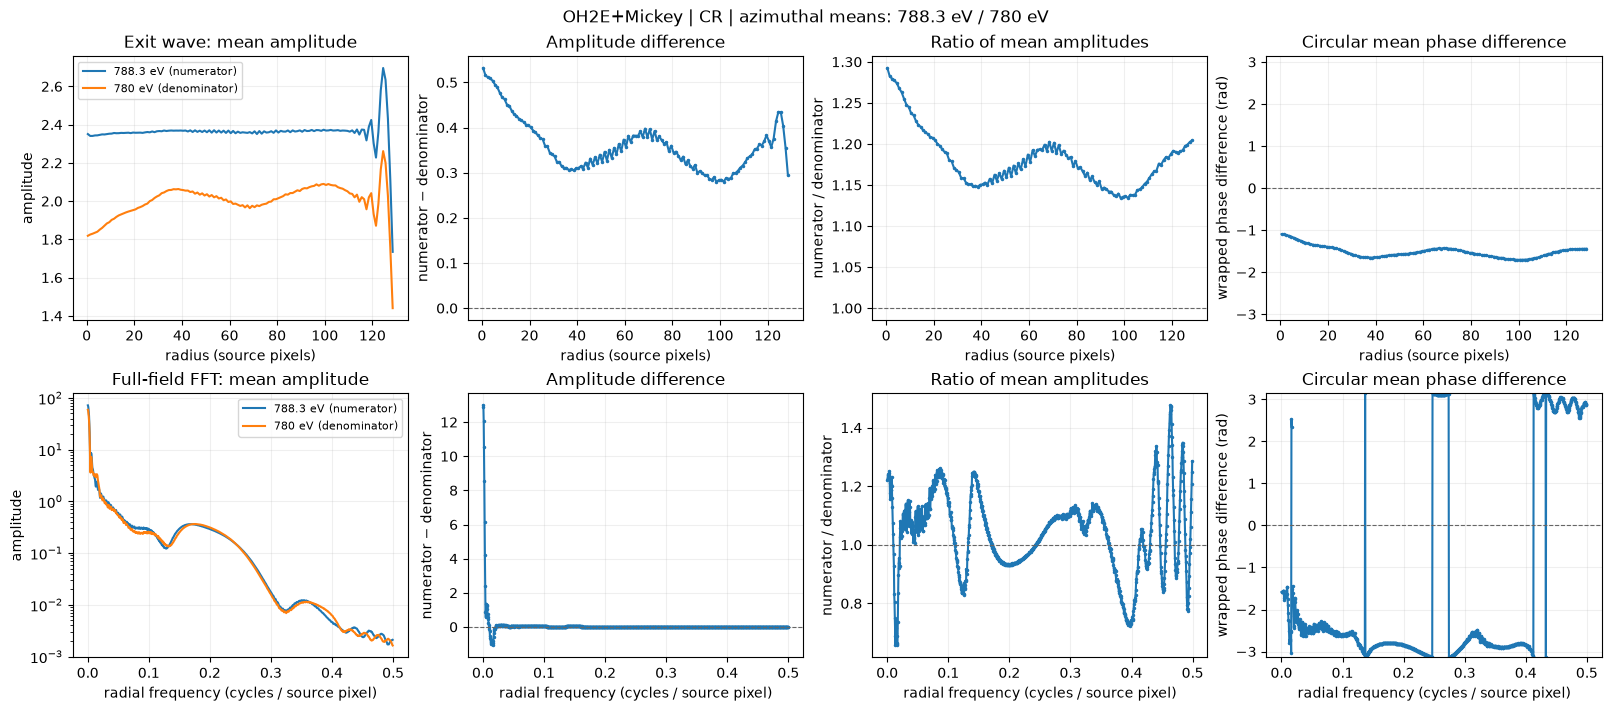

In [53]:
# Retain only small 1-D profiles; full fields are released after each pair.
azimuthal_results = {}
for label, path in FILES.items():
    for component in COMPONENTS:
        azimuthal_results[(label, component)] = plot_azimuthal_energy_comparison(
            path, catalog[label], label, component,
        )
